In [1]:


import sys
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns 


from sklearn.cluster import AgglomerativeClustering, KMeans , DBSCAN
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import StandardScaler , OneHotEncoder , FunctionTransformer

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score 



from sklearn.decomposition import PCA 

sys.path.append(os.path.abspath('..'))

from src import CATEGORICAL_COLUMNS , loader , NUMERICAL_COLUMNS , DROP_COLUMNS , BINARY_COLUMNS , GENDER_COLUMNS , CLUSTERING_DIR
df =  loader()


In [2]:
binary_encoding = FunctionTransformer(lambda x: x.replace({'Yes' : 1, 'No' : 0}) , feature_names_out='one-to-one')
gender_encoding = FunctionTransformer(lambda x: x.replace({'Male' : 1, 'Female' : 0}) , feature_names_out='one-to-one')


preprocessor = ColumnTransformer([
    ('numerical', Pipeline([
        ('imputer' , SimpleImputer(strategy='mean')) , 
        ('scaler' , StandardScaler()) 
    ]) , NUMERICAL_COLUMNS ) , 
    ('categorical' , Pipeline([
        ('imputer' , SimpleImputer(strategy='most_frequent') ) , 
        ('encoding', OneHotEncoder(handle_unknown='ignore' , sparse_output=False)) 
    ]), CATEGORICAL_COLUMNS ) ,
    ('binary' , Pipeline([
        ('encoding' , binary_encoding)
    ]), BINARY_COLUMNS ),
    ('gender' , Pipeline([
        ('encoding' , gender_encoding)
    ]), GENDER_COLUMNS )] , 
    remainder='drop'
)

df_preproce = preprocessor.fit_transform(df)

df_preproce = pd.DataFrame(
    df_preproce,
    columns=preprocessor.get_feature_names_out() , 
    index=df.index
)

df_preproce.head()



,numerical__tenure,numerical__MonthlyCharges,numerical__TotalCharges,categorical__MultipleLines_No,categorical__MultipleLines_No phone service,categorical__MultipleLines_Yes,categorical__InternetService_DSL,categorical__InternetService_Fiber optic,categorical__InternetService_No,categorical__OnlineSecurity_No,...,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,binary__SeniorCitizen,binary__Partner,binary__Dependents,binary__PhoneService,binary__PaperlessBilling,gender__gender
0,-1.277445,-1.160323,-0.994971,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0,1,0,0,1,0
1,0.066327,-0.259629,-0.173876,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0,0,0,1,0,1
2,-1.236724,-0.36266,-0.960399,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0,0,0,1,1,1
3,0.514251,-0.746535,-0.1954,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0,0,0,0,0,1
4,-1.236724,0.197365,-0.941193,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0,0,0,1,1,0


In [3]:
# K = 20
# nn = NearestNeighbors(n_neighbors=K) 
# distances, indices = nn.fit(df_preproce).kneighbors()

# kdist = np.sort(distances[:, K-1])

# plt.figure(figsize=(10, 5))
# plt.plot(kdist)
# plt.title('K-Distance Graph for DBSCAN')
# plt.xlabel('Data Points')
# plt.grid() 

# plt.show()


In [4]:
eps_values = [1.4, 1.5, 1.8, 2.0, 2.2, 2.4, 2.5]
min_samples_values = [3, 5, 7, 10]


for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )
    
        labels = dbscan.fit_predict(df_preproce)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = (labels == -1).mean() * 100

        print(
            f"eps={eps} | "
            f"clusters={n_clusters} | "
            f"min_samples={min_samples} | "
            f"noise={noise_pct:.2f}%"
        )
        

eps=1.4 | clusters=281 | min_samples=3 | noise=42.81%
eps=1.4 | clusters=130 | min_samples=5 | noise=52.21%
eps=1.4 | clusters=83 | min_samples=7 | noise=57.48%
eps=1.4 | clusters=56 | min_samples=10 | noise=61.98%
eps=1.5 | clusters=78 | min_samples=3 | noise=25.37%
eps=1.5 | clusters=22 | min_samples=5 | noise=32.95%
eps=1.5 | clusters=7 | min_samples=7 | noise=37.87%
eps=1.5 | clusters=6 | min_samples=10 | noise=41.94%
eps=1.8 | clusters=41 | min_samples=3 | noise=9.24%
eps=1.8 | clusters=14 | min_samples=5 | noise=14.64%
eps=1.8 | clusters=8 | min_samples=7 | noise=18.88%
eps=1.8 | clusters=4 | min_samples=10 | noise=23.94%
eps=2.0 | clusters=16 | min_samples=3 | noise=4.87%
eps=2.0 | clusters=13 | min_samples=5 | noise=8.25%
eps=2.0 | clusters=5 | min_samples=7 | noise=11.91%
eps=2.0 | clusters=6 | min_samples=10 | noise=16.24%
eps=2.2 | clusters=2 | min_samples=3 | noise=0.50%
eps=2.2 | clusters=2 | min_samples=5 | noise=0.74%
eps=2.2 | clusters=3 | min_samples=7 | noise=1.31%
ep

In [5]:
# silhouette = []
# wc = []
# k_range = range(2, 11)
# for k in k_range:
#     model = KMeans(n_clusters=k, random_state=42)
#     labels = model.fit_predict(df_preproce)


#     wc.append(model.inertia_)
#     silhouette_avg = silhouette_score(df_preproce, labels)
#     silhouette.append(silhouette_avg)


In [6]:
# fig , axes = plt.subplots(1, 2, figsize=(15, 5 ))

# sns.lineplot(x=k_range, y=silhouette , marker='o', linewidth=2, ax=axes[0])
# plt.title('Silhouette Score vs Number of Clusters')
# plt.xlabel('Number of Clusters')
# plt.ylabel('Silhouette Score')

# sns.lineplot(x=k_range, y=wc, marker='o', linewidth=2, ax=axes[1])
# plt.xlabel('Number of Clusters')
# plt.ylabel('WCSS')

In [7]:
kmeans = Pipeline([
    ('preprocessor', preprocessor ) , 
    ('kmeans' , KMeans(n_clusters=3 , random_state=42) )
])

db_scan = Pipeline([
    ('preprocessor', preprocessor ) ,
    ('dbscan' , DBSCAN(eps=1.8 , min_samples=10))
])

aggo = Pipeline([
    ('preprocessor', preprocessor ) ,
    ('agglo' , AgglomerativeClustering(n_clusters=3 , linkage='ward' ) )
])

cluster = {
    'kmeans' : kmeans ,
    'dbscan' : db_scan , 
    'aggo' : aggo 
}

pca = PCA(n_components=2) 

df_pca = pca.fit_transform(df_preproce)


In [8]:
model = cluster['kmeans'].fit(df)
labels_kmeans = model.named_steps['kmeans'].labels_  

pd.Series(labels_kmeans).value_counts().sort_index()

0    3198
1    2319
2    1526
Name: count, dtype: int64

In [9]:


dbscan_model = cluster['dbscan'].fit(df)
labels_dbscan = dbscan_model.named_steps['dbscan'].labels_

pd.Series(labels_dbscan).value_counts().sort_index()

-1    1686
 0     284
 1    3489
 2    1526
 3      58
Name: count, dtype: int64

In [10]:
aggo_model = cluster['aggo'].fit(df)
labels_aggo = aggo_model.named_steps['agglo'].labels_

pd.Series(labels_aggo).value_counts().sort_index()

0    3556
1    1526
2    1961
Name: count, dtype: int64

Text(0.5, 1.0, 'Agglomerative Clustering')

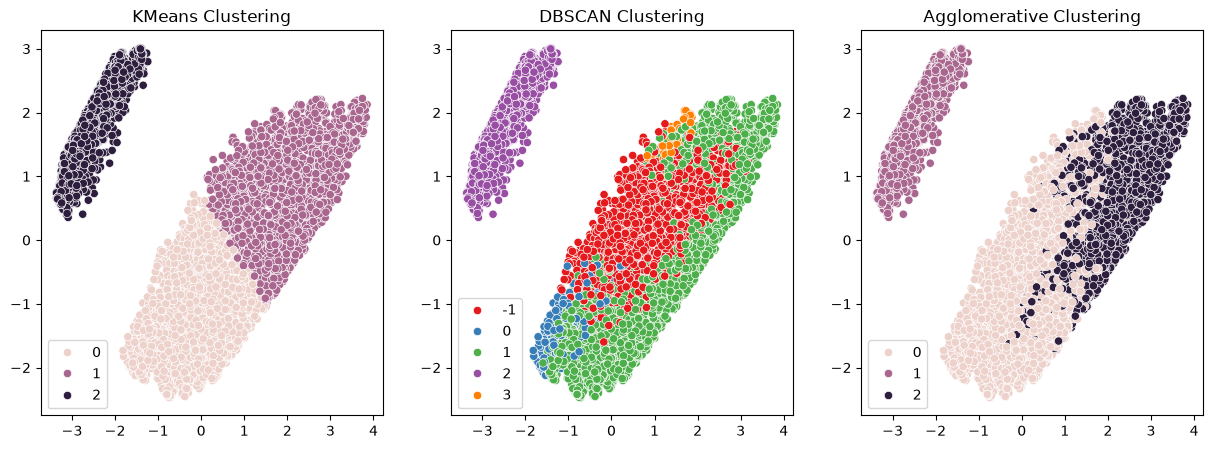

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.scatterplot(x=df_pca[:, 0] , y=df_pca[:, 1], hue=labels_kmeans, ax=axes[0])
axes[0].set_title('KMeans Clustering')

sns.scatterplot(x=df_pca[:, 0] , y=df_pca[:, 1], hue=labels_dbscan, ax=axes[1] , palette='Set1')
axes[1].set_title('DBSCAN Clustering')

sns.scatterplot(x=df_pca[:, 0] , y=df_pca[: , 1] , hue=labels_aggo , ax=axes[2]  ) ;
axes[2].set_title('Agglomerative Clustering')

In [12]:
def evaluate_clustering (X , labels , name , mask ) : 
    labels = np.array(labels) 
    Xm , lm = X[mask] , labels[mask] 
    print(set(lm))
    n_clusters = len(set(lm) - {-1})
    out = { 
       'model' : name , 
       'n_clusters' : n_clusters , 
       'noise' : round((labels == -1).mean() * 100, 2 ) 
    } 

    if n_clusters > 1 : 
        out.update({
            'silhouette_score' : silhouette_score(Xm, lm) ,
            'davies_bouldin_score' : davies_bouldin_score(Xm, lm) , 
            'calinski_harabasz_score' : calinski_harabasz_score(Xm, lm)
        })

    return out 


In [13]:
X = df_preproce.values 

all_labels = {
    'kmeans' : labels_kmeans ,
    'dbscan' : labels_dbscan ,
    'aggo' : labels_aggo
}

common_labels = labels_dbscan != -1


scores = pd.DataFrame([
    evaluate_clustering(X, labels, name, common_labels) for name, labels in all_labels.items()
])

print(scores)

{np.int32(0), np.int32(1), np.int32(2)}
{np.int64(0), np.int64(1), np.int64(2), np.int64(3)}
{np.int64(0), np.int64(1), np.int64(2)}
    model  n_clusters  noise  silhouette_score  davies_bouldin_score  \
0  kmeans           3   0.00          0.347481              1.213594   
1  dbscan           4  23.94          0.132122              1.474907   
2    aggo           3   0.00          0.323994              1.300860   

   calinski_harabasz_score  
0              2855.818812  
1               986.499085  
2              2588.654401  


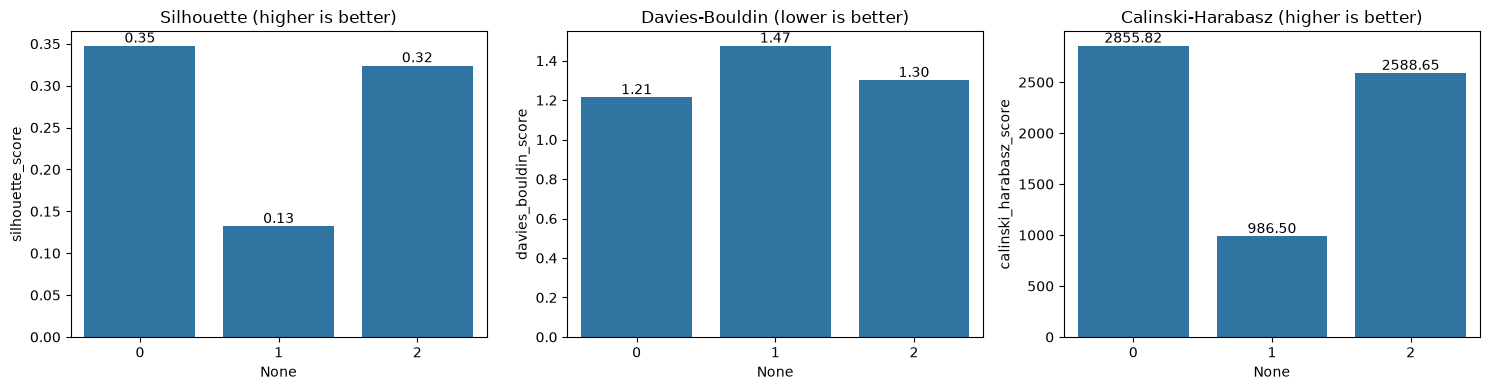

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes,
        ['silhouette_score', 'davies_bouldin_score', 'calinski_harabasz_score'],
        ['Silhouette (higher is better)', 'Davies-Bouldin (lower is better)', 'Calinski-Harabasz (higher is better)']):
    sns.barplot(x=scores.index, y=scores[col], ax=ax)
    ax.set_title(title)
    for c in ax.containers:
        ax.bar_label(c, fmt='%.2f')
plt.tight_layout(); plt.show()

In [15]:
# eps_values = [1.4, 1.6, 1.8, 2.0, 2.2, 2.5]
# ms_values  = [5, 10, 20, 40]
# rows = []
# for eps in eps_values:
#     for ms in ms_values:
#         lab = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
#         m = lab != -1
#         n_cl = len(set(lab[m]))
#         sil = silhouette_score(X[m], lab[m], sample_size=3000, random_state=42) if n_cl >= 2 else np.nan
#         dav = davies_bouldin_score(X[m], lab[m]) if n_cl >= 2 else np.nan
#         cal = calinski_harabasz_score(X[m], lab[m]) if n_cl >= 2 else np.nan
#         rows.append({'eps': eps, 'min_samples': ms, 'clusters': n_cl,
#                      'noise_%': (~m).mean() * 100, 'silhouette': sil, 'davies_bouldin': dav, 'calinski_harabasz': cal})
# grid = pd.DataFrame(rows)


In [16]:

# fig, axes = plt.subplots(1, 3, figsize=(18, 4))
# for ax, col in zip(axes, ['clusters', 'noise_%', 'silhouette']):
#     sns.heatmap(grid.pivot(index='min_samples', columns='eps', values=col),
#                 annot=True, fmt='.2g', cmap='viridis', ax=ax)
#     ax.set_title(col)
# plt.tight_layout(); plt.show()


# fig, axes = plt.subplots(1, 3, figsize=(18, 4))
# for ax, col in zip(axes, ['clusters', 'noise_%', 'davies_bouldin']):
#     sns.heatmap(grid.pivot(index='min_samples', columns='eps', values=col),
#                 annot=True, fmt='.2g', cmap='viridis', ax=ax)
#     ax.set_title(col)
# plt.tight_layout(); plt.show()


# fig, axes = plt.subplots(1, 3, figsize=(18, 4))
# for ax, col in zip(axes, ['clusters', 'noise_%', 'calinski_harabasz']):
#     sns.heatmap(grid.pivot(index='min_samples', columns='eps', values=col),
#                 annot=True, fmt='.2g', cmap='viridis', ax=ax)
#     ax.set_title(col)
# plt.tight_layout(); plt.show()

In [17]:
df['Cluster'] = labels_kmeans 

/tmp/ipykernel_257310/1813831700.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Cluster' ,ax=axes[0] , palette='Set2' )


Text(0, 0.5, 'Count')

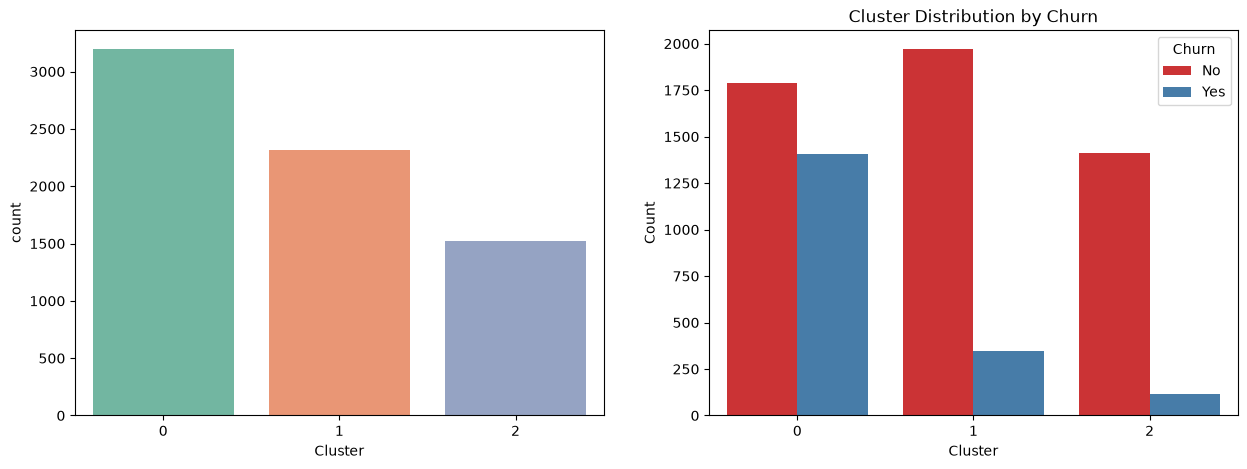

In [18]:
fig , axes = plt.subplots(1, 2, figsize=(15, 5))    

sns.countplot(data=df, x='Cluster' ,ax=axes[0] , palette='Set2' )
plt.title('Cluster Distribution')
plt.xlabel('Cluster')
plt.ylabel('Count')

sns.countplot(data=df, x='Cluster' , hue='Churn' , ax=axes[1] , palette='Set1') 
plt.title('Cluster Distribution by Churn')
plt.xlabel('Cluster')
plt.ylabel('Count')

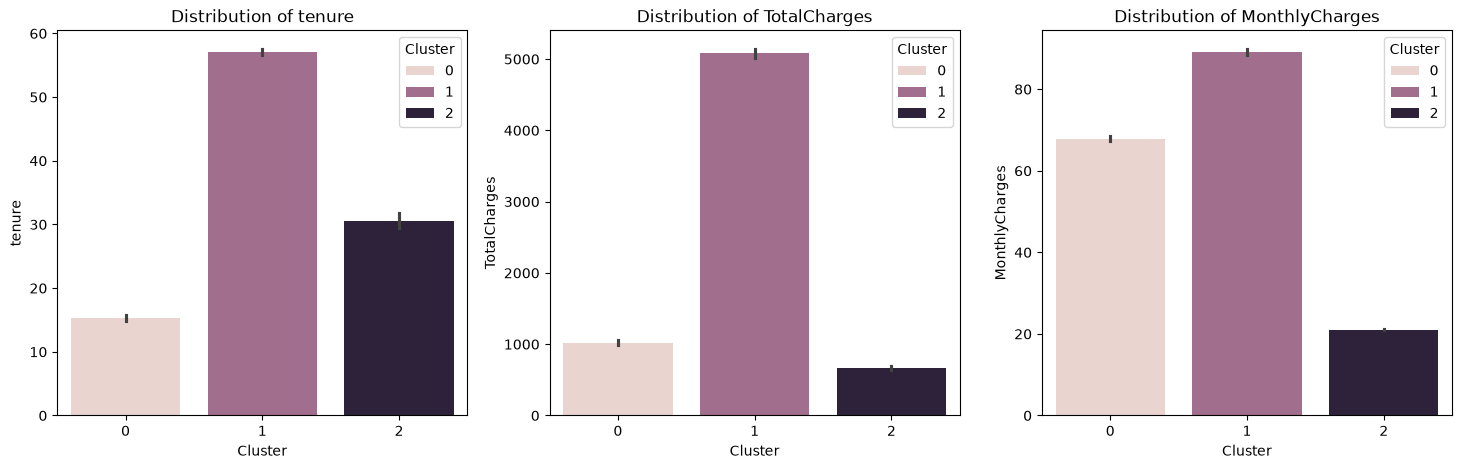

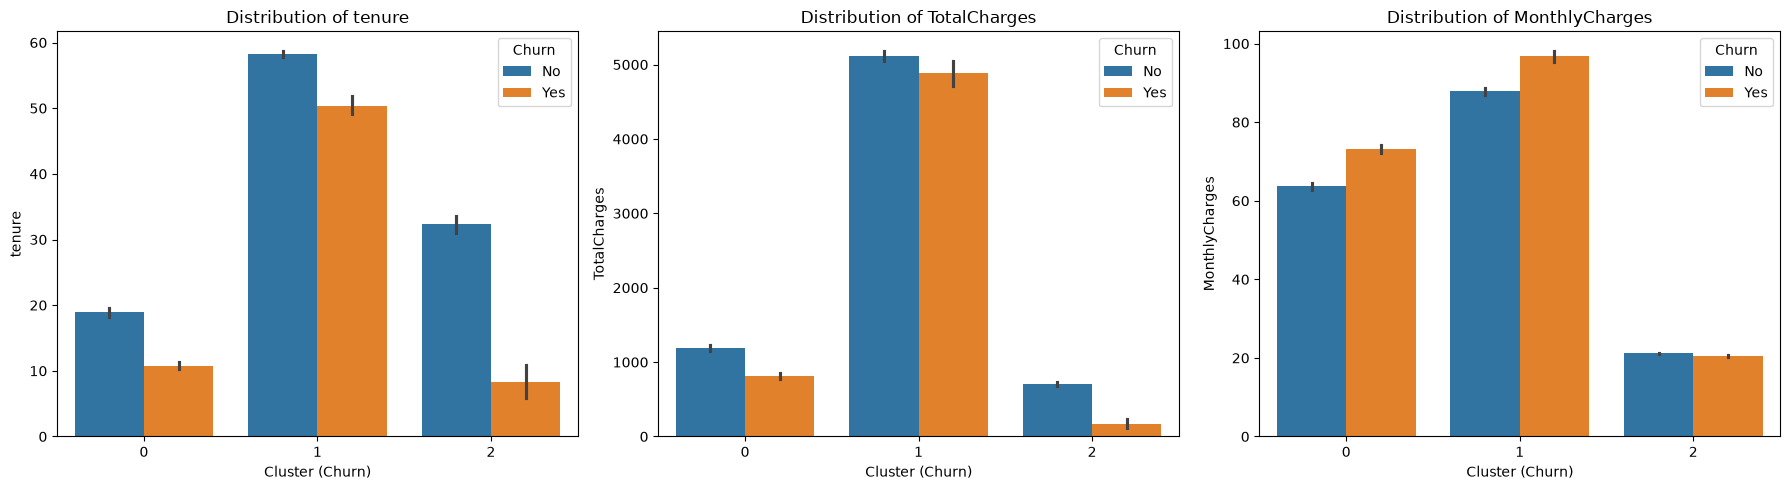

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['tenure' , 'TotalCharges' , 'MonthlyCharges']):
    sns.barplot(data=df, x='Cluster' , hue='Cluster' , y=col  , ax=ax )
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Cluster')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['tenure' , 'TotalCharges' , 'MonthlyCharges']):
    sns.barplot(data=df, x='Cluster' , hue='Churn' , y=col  , ax=ax )
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Cluster (Churn)')



plt.tight_layout()

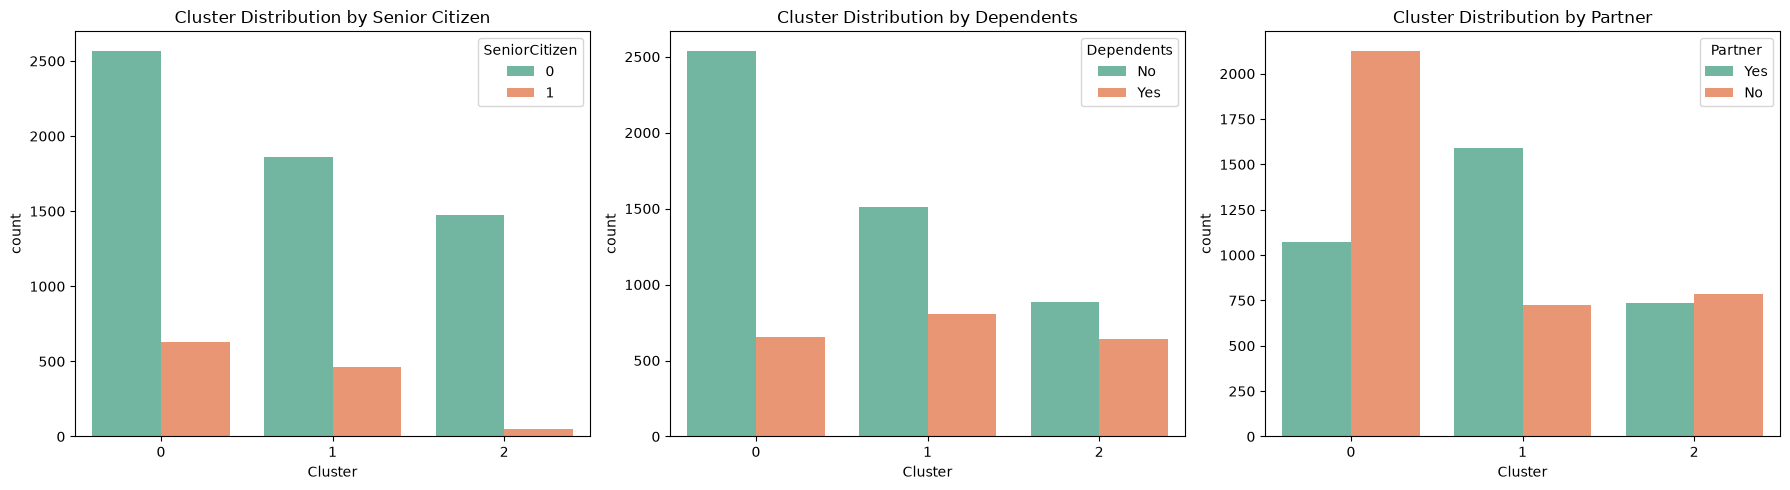

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='Cluster' , hue='SeniorCitizen' , ax=axes[0] , palette='Set2' )
axes[0].set_title('Cluster Distribution by Senior Citizen') 
axes[0].set_xlabel('Cluster')


sns.countplot(data=df, x='Cluster' , hue='Dependents' , ax=axes[1], palette='Set2' )
axes[1].set_title('Cluster Distribution by Dependents')
axes[1].set_xlabel('Cluster')

sns.countplot(data=df, x='Cluster' , hue='Partner' , ax=axes[2] , palette='Set2' )
axes[2].set_title('Cluster Distribution by Partner')
axes[2].set_xlabel('Cluster')

plt.tight_layout()


Text(0.5, 29.336588541666686, 'Internet Service')

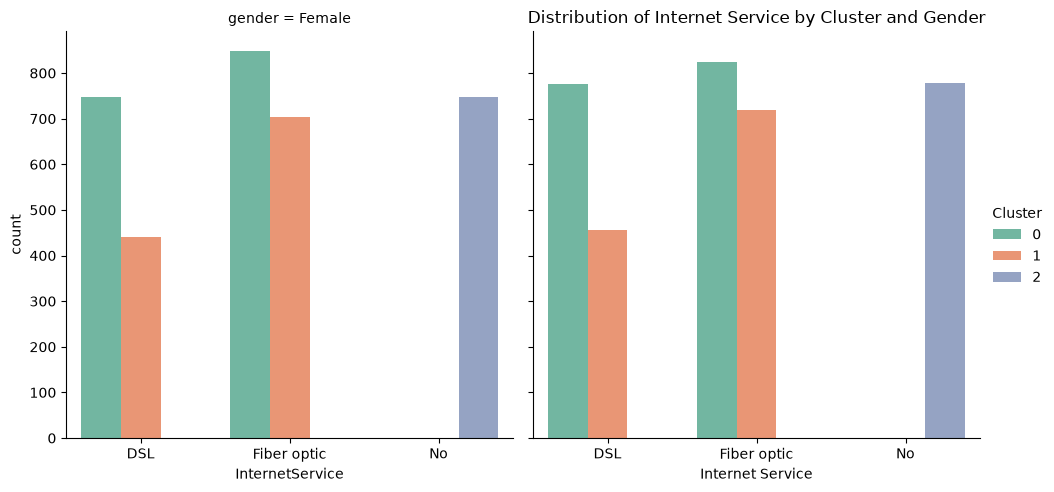

In [21]:

sns.catplot(data=df, x='InternetService' , hue='Cluster' , col='gender' , kind='count' , palette='Set2' )
plt.title('Distribution of Internet Service by Cluster and Gender')
plt.xlabel('Internet Service')





Text(0.5, 0, 'Paperless Billing')

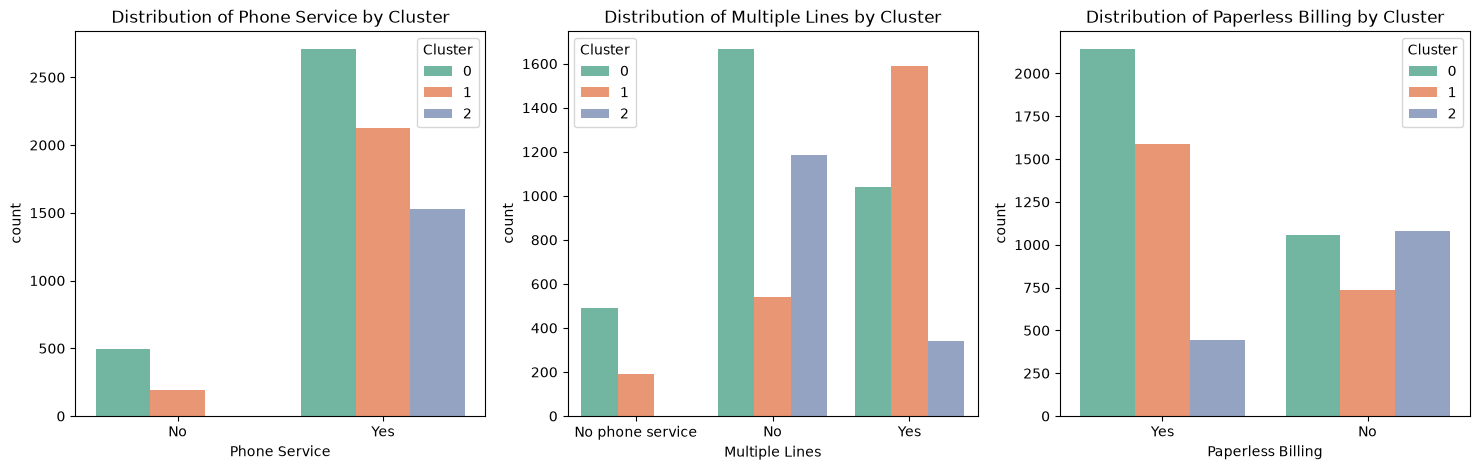

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='PhoneService' , hue='Cluster' , ax=axes[0] , palette='Set2' )
axes[0].set_title('Distribution of Phone Service by Cluster')
axes[0].set_xlabel('Phone Service')

sns.countplot(data=df, x='MultipleLines' , hue='Cluster' , ax=axes[1] , palette='Set2' )
axes[1].set_title('Distribution of Multiple Lines by Cluster')
axes[1].set_xlabel('Multiple Lines')

sns.countplot(data=df, x='PaperlessBilling' , hue='Cluster' , ax=axes[2] , palette='Set2' )
axes[2].set_title('Distribution of Paperless Billing by Cluster')
axes[2].set_xlabel('Paperless Billing')


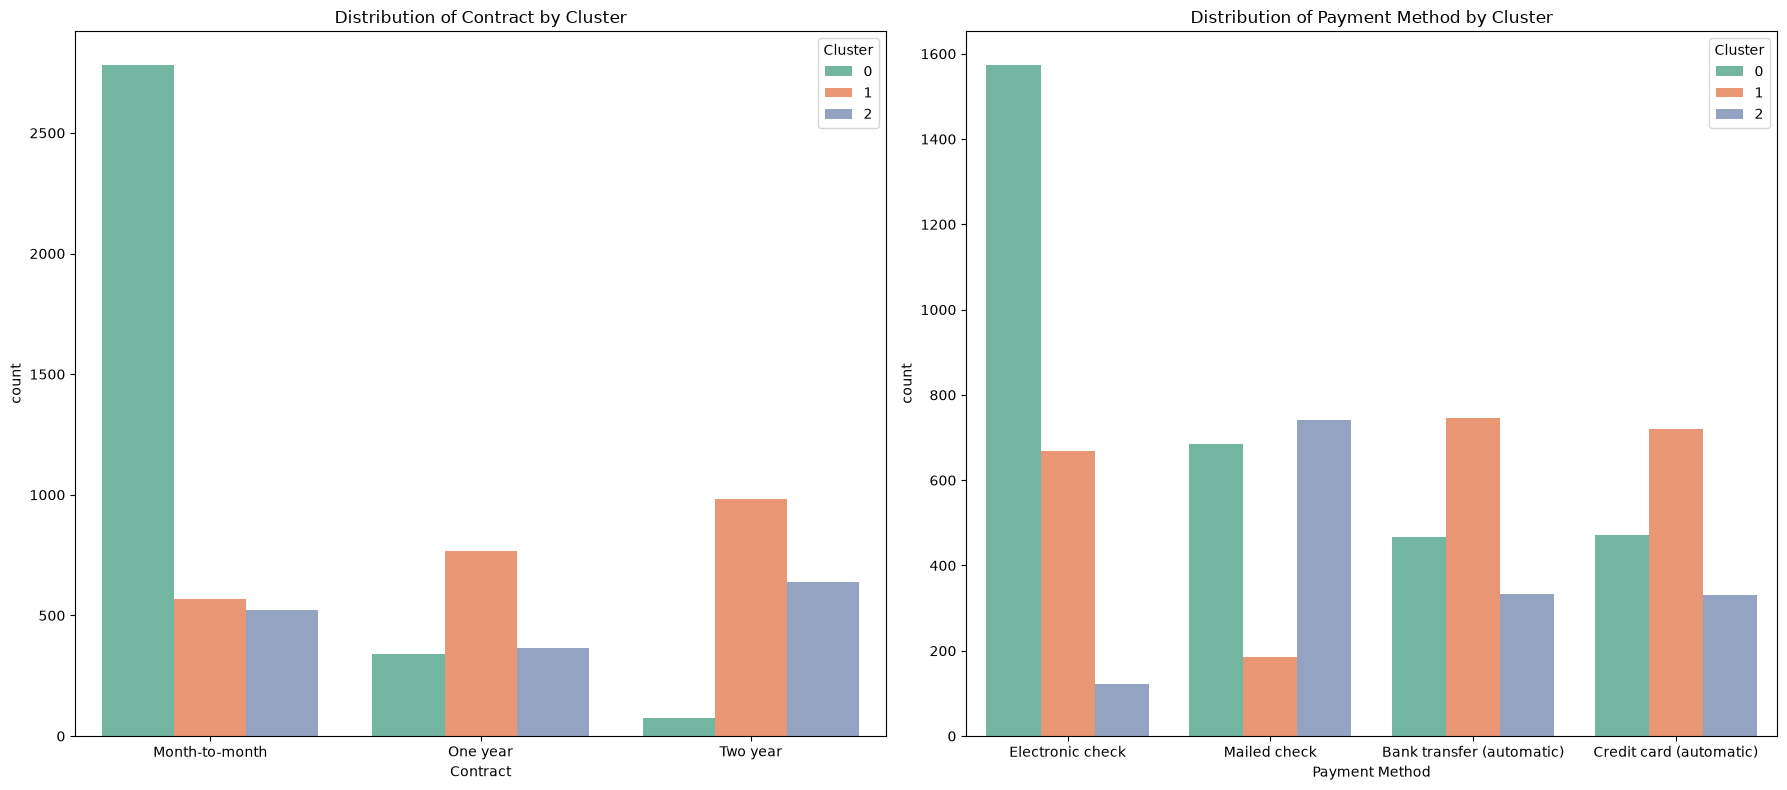

In [23]:
fig, axes = plt.subplots(1, 2 , figsize=(18, 8))

sns.countplot(data=df, x='Contract',  hue='Cluster' , ax=axes[0] , palette='Set2' )
axes[0].set_title('Distribution of Contract by Cluster')
axes[0].set_xlabel('Contract')

sns.countplot(data=df, x='PaymentMethod' , hue='Cluster' , ax=axes[1] , palette='Set2' )
axes[1].set_title('Distribution of Payment Method by Cluster')
axes[1].set_xlabel('Payment Method')


plt.tight_layout()

In [24]:
labels_cluster = {
    0 : 'New_M2M_AtRisk' , 
    1 : 'Loyal_Premium_HighValue' , 
    2 : 'Basic_PhoneOnly_LowRisk'
}

In [ ]:
df["Cluster"] = df["Cluster"].map(labels_cluster)
df.to_csv(CLUSTERING_DIR, index=False)